In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
%matplotlib inline

In [2]:
df = pd.read_csv('data/csvs/examenes.csv')
df = df.sample(n = 100, replace = False)

In [4]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
15138,15139,20,other,diploma,5.17,65.4,yes,4.8,average,coaching,low,moderate,50.4
15626,15627,21,female,ba,7.71,99.4,yes,7.6,average,online videos,medium,easy,76.8
18327,18328,21,male,ba,1.69,62.9,yes,7.4,poor,mixed,low,easy,36.2
6813,6814,21,male,bca,1.11,57.1,yes,7.4,average,coaching,high,moderate,53.0
4607,4608,20,female,ba,1.58,89.8,no,6.0,good,online videos,medium,hard,67.1


In [81]:
X = np.array(df[["study_hours"]])
y = np.array(df["exam_score"])


#X = sm.add_constant(X)

model = sm.OLS(y, X)

result = model.fit()

#print(result.predict(7))

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.886
Model:                            OLS   Adj. R-squared (uncentered):              0.885
Method:                 Least Squares   F-statistic:                              768.8
Date:                Sat, 28 Feb 2026   Prob (F-statistic):                    1.82e-48
Time:                        19:23:21   Log-Likelihood:                         -452.69
No. Observations:                 100   AIC:                                      907.4
Df Residuals:                      99   BIC:                                      910.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            13.5268      0.488     27.728      0.000      12.559      14.495
==============================================================================
Omnibus:                        1.114   Durbin-Watson:                   1.549
Prob(Omnibus):                  0.573   Jarque-Bera (JB):                1.094
Skew:                          -0.119   Prob(JB):                        0.579
Kurtosis:                       2.546   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

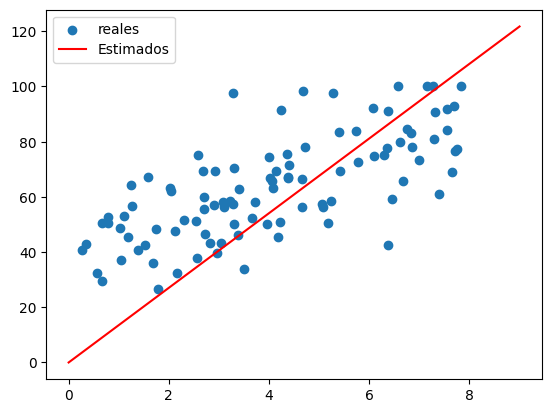

In [66]:
x = np.linspace(0,9, 50)
y_pred = result.predict(x)

plt.scatter(X, y, label = "reales")
plt.plot(x,y_pred, color = "r", label = "Estimados")
plt.legend()

residuo = y_real - y_estimada

In [74]:
print(X[0], y[0], result.predict(X[0]))

[5.17] 50.4 [69.93352801]


Text(0, 0.5, 'Residuos')

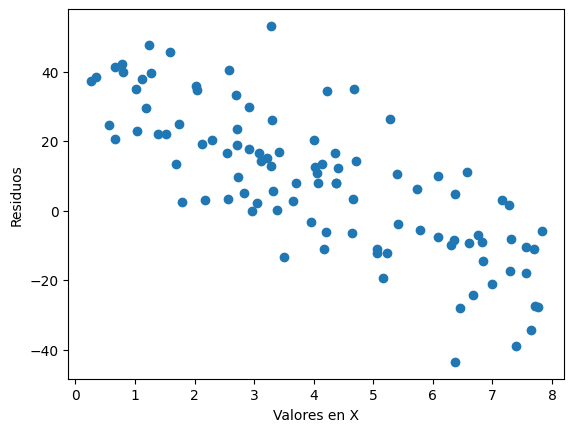

In [82]:
residuos = []
X = list(X)
y = list(y)
for i in range(len(X)):
    residuos.append(y[i] - result.predict(X[i]))
    
plt.scatter(X, residuos)
plt.xlabel("Valores en X")
plt.ylabel("Residuos")

Rompe los supuestos de la regresion lineal